## Veridi Logistics Delivery Performance Audit

## importing packages


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

## loading dataset

In [2]:
orders = pd.read_csv("../data/olist_orders_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
translations = pd.read_csv("../data/product_category_name_translation.csv")

## confirming  the dataset

In [3]:
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Order Items:", items.shape)
print("Translations:", translations.shape)

Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Order Items: (112650, 7)
Translations: (71, 2)


## look at the dataset

In [4]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [6]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## Understand the Tables

In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [8]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


## Check Missing Values

In [10]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 ## Observation:
Most orders are delivered. Some are canceled or unavailable, which explains the missing delivery dates.

In [11]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Check Missing Values by Status
### Missing Values Investigation

 Missing delivery dates are expected.
Most missing values occur because orders were canceled, unavailable, or not yet delivered.
These records will not be deleted.
They will be flagged as "Undelivered" and excluded from delay calculations.

In [12]:
orders.groupby("order_status")[
    "order_delivered_customer_date"
].apply(lambda x: x.isna().sum())

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_delivered_customer_date, dtype: int64

In [13]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [14]:
reviews[["review_comment_title", "review_comment_message"]].value_counts()

review_comment_title  review_comment_message                                                              
Bom                   Bom                                                                                     16
Ótimo                 Ótimo                                                                                   11
bom                   bom                                                                                     10
recomendo             recomendo                                                                               10
Muito bom             Muito bom                                                                                9
                                                                                                              ..
                      Tudo certo, chegou no tempo certo e veio tudo ok                                         1
                      Tudo perfeito, entregou antes do previsto e produto era o mesmo da foto e descri

In [15]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

## Check Duplicate Reviews

In [16]:
reviews["order_id"].duplicated().sum()

np.int64(551)

In [17]:
reviews = (
    reviews
    .sort_values("review_creation_date")
    .drop_duplicates(
        subset="order_id",
        keep="last"
    )
)
reviews["order_id"].duplicated().sum()

np.int64(0)

In [18]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [19]:
reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [20]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

# Build the Master Dataset
## Merge Orders and Reviews

In [21]:
master = orders.merge(
    reviews,
    on="order_id",
    how="left"
)


In [22]:
master.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   review_id                      98673 non-null  object 
 9   review_score                   98673 non-null  float64
 10  review_comment_title           11552 non-null  object 
 11  review_comment_message         40776 non-null  object 
 12  review_creation_date           98673 non-null 

## Add Customers

In [23]:
master = master.merge(
    customers,
    on="customer_id",
    how="left"
)

In [24]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   review_id                      98673 non-null  object 
 9   review_score                   98673 non-null  float64
 10  review_comment_title           11552 non-null  object 
 11  review_comment_message         40776 non-null  object 
 12  review_creation_date           98673 non-null 

## Adding product(join the product to the items)


In [25]:
products = products.merge(
    translations,
    on="product_category_name",
    how="left"
)

In [26]:
translations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [27]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32341 non-null  object 
 2   product_name_lenght            32341 non-null  float64
 3   product_description_lenght     32341 non-null  float64
 4   product_photos_qty             32341 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32328 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


In [28]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [29]:
items_products = items.merge(
    products,
    on="product_id",
    how="left"
)

In [30]:
items_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product_category_name          111047 non-null  object 
 8   product_name_lenght            111047 non-null  float64
 9   product_description_lenght     111047 non-null  float64
 10  product_photos_qty             111047 non-null  float64
 11  product_weight_g               112632 non-null  float64
 12  product_length_cm             

## Add Product Categories to Master

In [31]:
master = master.merge(
    items_products[
        [
            "order_id",
            "product_category_name_english"  # Fixed: removed the leading space
        ]
    ],
    on="order_id",
    how="left"
)

In [32]:
master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'product_category_name_english'],
      dtype='object')

In [33]:
master.shape
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   review_id                      112464 non-null  object 
 9   review_score                   112464 non-null  float64
 10  review_comment_title           13506 non-null   object 
 11  review_comment_message         47924 non-null   object 
 12  review_creation_date          

 ## Convert Dates

In [34]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    master[col] = pd.to_datetime(
        master[col],
        errors="coerce"
    )

In [35]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 19 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   review_id                      112464 non-null  object        
 9   review_score                   112464 non-null  float64       
 10  review_comment_title           13506 non-null   object        
 11  

## Create Delay Metric

Negative = Delivered early
0 = Delivered on time
Positive = Delivered late

In [36]:
master["delay_days"] = (
    master["order_delivered_customer_date"]
    -
    master["order_estimated_delivery_date"]
).dt.days

In [37]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   review_id                      112464 non-null  object        
 9   review_score                   112464 non-null  float64       
 10  review_comment_title           13506 non-null   object        
 11  

In [38]:
master["days_difference"] = (
    master["order_estimated_delivery_date"]
    -
    master["order_delivered_customer_date"]
).dt.days

In [39]:
master.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  161
order_delivered_carrier_date      1968
order_delivered_customer_date     3229
order_estimated_delivery_date        0
review_id                          961
review_score                       961
review_comment_title             99919
review_comment_message           65501
review_creation_date               961
review_answer_timestamp            961
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
product_category_name_english     2402
delay_days                        3229
days_difference                   3229
dtype: int64

In [40]:
conditions = [
    master["delay_days"] <= 0,
    (
        (master["delay_days"] > 0)
        &
        (master["delay_days"] <= 5)
    ),
    master["delay_days"] > 5
]

choices = [
    "On Time",
    "Late",
    "Super Late"
]

master["delivery_status"] = np.select(
    conditions,
    choices,
    default="Undelivered"
)

In [41]:
master

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,delay_days,days_difference,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,housewares,-8.0,7.0,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumery,-6.0,5.0,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,auto,-18.0,17.0,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,-13.0,12.0,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,stationery,-10.0,9.0,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,29bb71b2760d0f876dfa178a76bc4734,4.0,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,baby,-2.0,1.0,On Time
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,371579771219f6db2d830d50805977bb,5.0,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,home_appliances_2,-6.0,5.0,On Time
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,computers_accessories,-21.0,20.0,On Time
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,computers_accessories,-21.0,20.0,On Time


## Flag Undelivered Orders

In [42]:
master.loc[
    master["order_status"].isin(
        ["canceled", "unavailable"]
    ),
    "delivery_status"
] = "Undelivered"

In [43]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   review_id                      112464 non-null  object        
 9   review_score                   112464 non-null  float64       
 10  review_comment_title           13506 non-null   object        
 11  

# deleting missing and duplicate data

In [44]:
master.isnull().sum()
master.shape

(113425, 22)

In [45]:
master.duplicated().sum()


np.int64(13180)

In [75]:
print(f"New dataset shape: {master.shape}")


New dataset shape: (108622, 22)


In [76]:
master.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_id                        0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name_english    0
delay_days                       0
days_difference                  0
delivery_status                  0
dtype: int64

# Drop rows where critical delivery or product data is missing

In [77]:

master = master.dropna(subset=[
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date",
    "product_category_name_english"
])


master["delay_days"] = (master["order_delivered_customer_date"] - master["order_estimated_delivery_date"]).dt.days
master["days_difference"] = (master["order_delivered_customer_date"] - master["order_purchase_timestamp"]).dt.days


print(f"Cleaned dataset shape: {master.shape}")
master.isnull().sum()

Cleaned dataset shape: (108622, 22)


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_id                        0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name_english    0
delay_days                       0
days_difference                  0
delivery_status                  0
dtype: int64

#  Fill missing review text with a placeholder

In [78]:

master["review_comment_title"] = master["review_comment_title"].fillna("No Title")
master["review_comment_message"] = master["review_comment_message"].fillna("No Message")


master["review_score"] = master["review_score"].fillna(0) # 0 means 'Not Rated'
master["review_id"] = master["review_id"].fillna("No Review")


master.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_id                        0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name_english    0
delay_days                       0
days_difference                  0
delivery_status                  0
dtype: int64

# Fill missing timestamps with a clear placeholder date (Jan 1, 1900)

In [79]:
placeholder_date = pd.to_datetime("2016-10-11")

master["review_creation_date"] = master["review_creation_date"].fillna(placeholder_date)
master["review_answer_timestamp"] = master["review_answer_timestamp"].fillna(placeholder_date)

# Final check
master.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_id                        0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
product_category_name_english    0
delay_days                       0
days_difference                  0
delivery_status                  0
dtype: int64

In [51]:
master

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name_english,delay_days,days_difference,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,housewares,-8,8,On Time
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,perfumery,-6,13,On Time
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Message,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,auto,-18,9,On Time
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5.0,No Title,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,pet_shop,-13,13,On Time
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5.0,No Title,No Message,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,stationery,-10,2,On Time
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,29bb71b2760d0f876dfa178a76bc4734,4.0,No Title,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,baby,-2,22,On Time
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,371579771219f6db2d830d50805977bb,5.0,No Title,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,home_appliances_2,-6,24,On Time
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,No Title,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,computers_accessories,-21,17,On Time
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,8ab6855b9fe9b812cd03a480a25058a1,2.0,No Title,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,computers_accessories,-21,17,On Time


# Exploratory Analysis

## The "Real" Delay Calculator

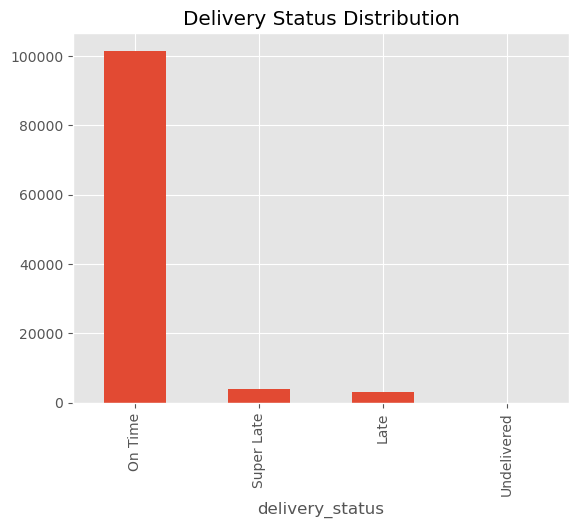

In [52]:
master["delivery_status"].value_counts()
#visual
master["delivery_status"] \
      .value_counts() \
      .plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.show()

# Geographic Analysis

In [53]:
delivered = master[
    master["delivery_status"] != "Undelivered"
]

## Late Percentage by State

In [54]:
late_by_state = (
    delivered
    .assign(
        is_late=lambda x:
        x["delivery_status"]
        .isin(["Late", "Super Late"])
    )
    .groupby("customer_state")
    .agg(
        total_orders=("order_id", "count"),
        late_orders=("is_late", "sum")
    )
)

late_by_state["late_pct"] = (
    late_by_state["late_orders"]
    /
    late_by_state["total_orders"]
) * 100

late_by_state = (
    late_by_state
    .sort_values(
        "late_pct",
        ascending=False
    )
)

late_by_state.head()


,total_orders,late_orders,late_pct
customer_state,,,
AL,423,88,20.803783
MA,790,144,18.227848
SE,373,61,16.353887
PI,516,70,13.565891
CE,1409,187,13.271824


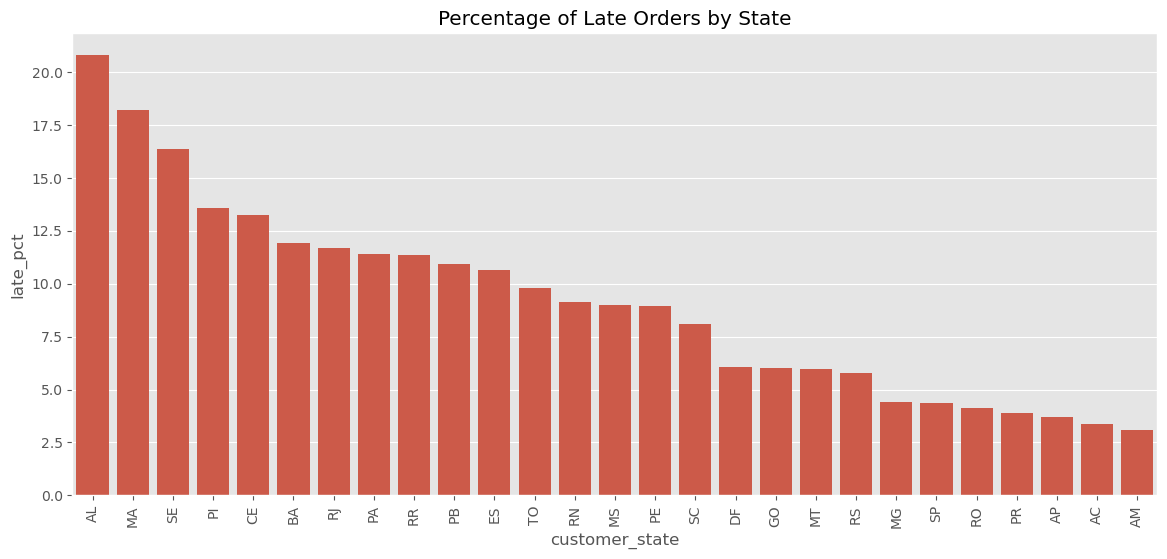

In [55]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=late_by_state.index,
    y=late_by_state["late_pct"]
)

plt.xticks(rotation=90)
plt.title(
    "Percentage of Late Orders by State"
)
plt.show()

# Customer Sentiment

In [56]:
delivered.groupby(
    "delivery_status"
)["review_score"].mean()

delivery_status
Late          2.899086
On Time       4.183536
Super Late    1.678580
Name: review_score, dtype: float64

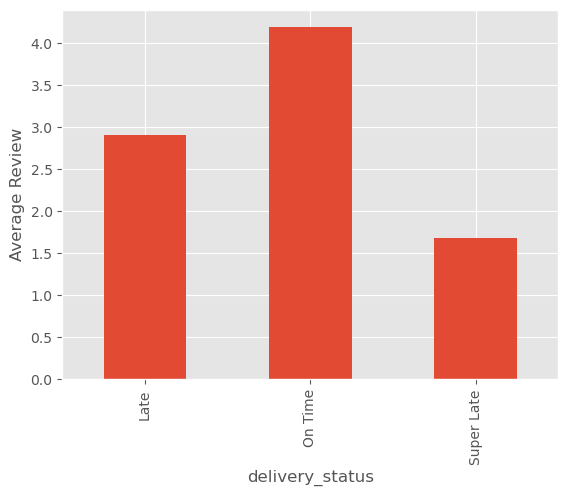

In [57]:
delivered.groupby(
    "delivery_status"
)["review_score"] \
.mean() \
.plot(kind="bar")

plt.ylabel("Average Review")
plt.show()

# Delay vs Review

In [58]:
delay_review = (
    delivered
    .groupby("delay_days")
    ["review_score"]
    .mean()
    .reset_index()
)

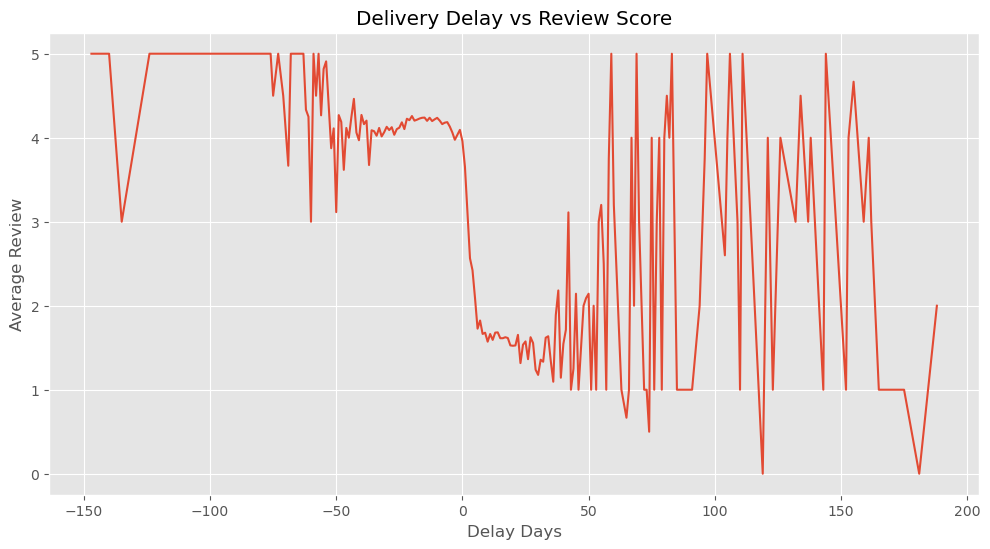

In [59]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=delay_review,
    x="delay_days",
    y="review_score"
)

plt.xlabel("Delay Days")
plt.ylabel("Average Review")
plt.title(
    "Delivery Delay vs Review Score"
)

plt.show()

# Product Analysis

## The "Translation" Challenge

In [60]:
category_delay = (
    delivered
    .groupby(
        "product_category_name_english"
    )
    ["delay_days"]
    .mean()
    .sort_values(
        ascending=False
    )
)

In [61]:
category_delay.head(10)

product_category_name_english
arts_and_craftmanship                -6.791667
furniture_mattress_and_upholstery    -7.162162
home_comfort_2                       -8.433333
home_confort                         -9.811189
food                                 -9.867735
audio                               -10.149171
fashion_underwear_beach             -10.929134
electronics                         -11.139978
books_imported                      -11.192982
construction_tools_lights           -11.222591
Name: delay_days, dtype: float64

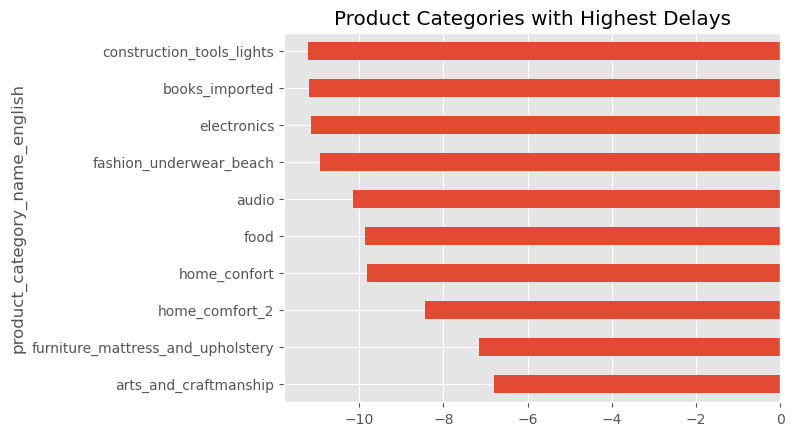

In [62]:
category_delay.head(10).plot(
    kind="barh"
)

plt.title(
    "Product Categories with Highest Delays"
)

plt.show()

# Candidate's Choice

In [63]:
state_performance = (
    delivered
    .groupby("customer_state")
    .agg(
        avg_delay=("delay_days", "mean"),
        avg_review=("review_score", "mean")
    )
    .reset_index()
)

# saving the cleaned dataset

In [64]:

master.to_csv("Master_logistics_data.csv", index=False)

print("Success! Your cleaned dataset has been saved as 'Master_logistics_data.csv'.")

Success! Your cleaned dataset has been saved as 'Master_logistics_data.csv'.


In [65]:
# Create the hidden .gitignore file automatically
with open(".gitignore", "w") as f:
    f.write("*.csv\n*.xlsx\n.ipynb_checkpoints/\n__pycache__/\n")

print("Success! .gitignore created locally.")

Success! .gitignore created locally.


In [66]:
with open(".gitignore", "w") as f:
    f.write("*.csv\n*.xlsx\n.ipynb_checkpoints/\n__pycache__/\n")
    

In [80]:
!git init


Initialized empty Git repository in C:/Users/JB/veridi-logistics-audit/notebooks/.git/


In [83]:
!git commit -m "first commit"


On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	delivery_audit.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add .gitignore 